In [12]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation
import diffrax as dfx
import diffrax as diffrax
from PIL import Image
import numpy as np

from pde_opt.numerics.domains import Domain
from pde_opt.numerics.shapes import Shape
from pde_opt.numerics.equations.allen_cahn import AllenCahn2DSmoothedBoundaryButlerVolmerConstantCurrent
from pde_opt.pde_model import PDEModel
from pde_opt.numerics.solvers import ROCK2JAX

In [13]:
jax.config.update('jax_enable_x64', True)

In [14]:
binary_mask = np.zeros((200, 200))
center = (100, 100)
radius = 75
y, x = np.ogrid[:200, :200]
dist_from_center = np.sqrt((x - center[0]) ** 2 + (y - center[1]) ** 2)
binary_mask[dist_from_center <= radius] = 1

shape = Shape(
    binary=jnp.array(binary_mask),
    dx=(1.0, 1.0),
    smooth_epsilon=3.0,
    smooth_curvature=0.008,
    smooth_dt=0.01,
    smooth_tf=100.0,
)

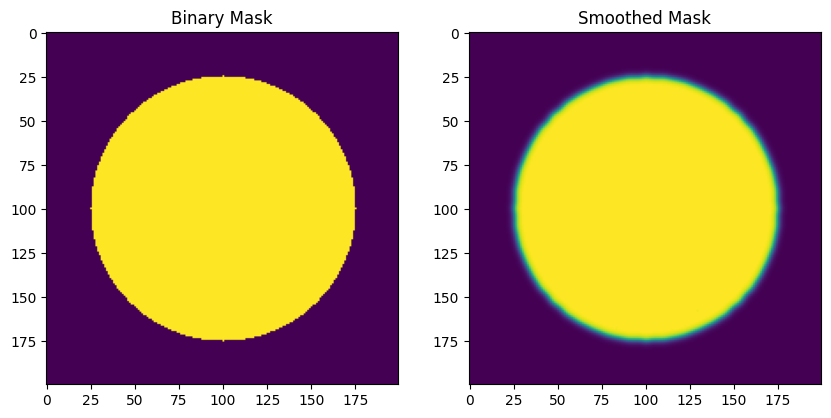

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(shape.binary)
axs[0].set_title("Binary Mask")
axs[1].imshow(shape.smooth)
axs[1].set_title("Smoothed Mask")
plt.show()

In [16]:
Nx, Ny = binary_mask.shape
Lx = 0.01 * Nx
Ly = 0.01 * Ny

domain = Domain(
    (Nx, Ny), ((-Lx / 2, Lx / 2), (-Ly / 2, Ly / 2)), "dimensionless", shape
)

In [17]:
t_start = 0.0
t_final = 70
dt = 0.000001

ts_save = jnp.linspace(t_start, t_final, 200)

kappa = 0.002

In [18]:
eq = AllenCahn2DSmoothedBoundaryButlerVolmerConstantCurrent(
    domain,
    kappa,
    lambda c: c * jnp.log(c) + (1.0 - c) * jnp.log(1.0 - c) + 3.0 * c * (1.0 - c) + 0.059,
    lambda c: jnp.log(c / (1.0 - c)) + 3.0 * (1.0 - 2.0 * c),
    lambda c: jnp.sqrt(c)*(1.0 - c),
    0.5,
    0.02,
    derivs="fd"
)

solver_tsit = dfx.Tsit5()

In [19]:
key = random.PRNGKey(0)
u0 = jnp.clip(0.1 * jnp.ones((Nx, Ny)) + 0.1 * random.normal(key, (Nx, Ny)), 0.05, 1.0)
print(jnp.max(u0))
print(jnp.min(u0))

0.49981978034999486
0.05


In [20]:
solution_tsit = diffrax.diffeqsolve(
    diffrax.ODETerm(jax.jit(lambda t, y, args: eq.rhs(y, t))),
    solver_tsit,
    t0=t_start,
    t1=t_final,
    dt0=dt,
    y0=u0,
    stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6),
    saveat=diffrax.SaveAt(ts=ts_save),
    max_steps=1000000,
)

In [21]:
solver_rock = ROCK2JAX(min_stages=0, max_stages=200)

In [22]:
solution_rock = diffrax.diffeqsolve(
    diffrax.ODETerm(jax.jit(lambda t, y, args: eq.rhs(y, t))),
    solver_rock,
    t0=t_start,
    t1=t_final,
    dt0=dt,
    y0=u0,
    stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6),
    saveat=diffrax.SaveAt(ts=ts_save),
    max_steps=1000000,
)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# --- parameters ---
stride = 10   # sample every Nth state
vmin, vmax = 0.0, 1.0

# Prepare frame indices (same length so both sides advance together)
idx_tsit = np.arange(0, len(solution_tsit.ys), stride)
idx_rock = np.arange(0, len(solution_rock.ys), stride)
n_frames = min(len(idx_tsit), len(idx_rock))
idx_tsit = idx_tsit[:n_frames]
idx_rock = idx_rock[:n_frames]

# Common imshow kwargs
extent = [domain.box[0][0], domain.box[0][1], domain.box[1][0], domain.box[1][1]]

# Initial images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

im1 = ax1.imshow(
    np.asarray(solution_tsit.ys[idx_tsit[0]]) * np.asarray(domain.geometry.binary),
    vmin=vmin, vmax=vmax, extent=extent, animated=True, origin="upper"
)
ax1.set_title("Tsit5")
ax1.set_xlabel("x"); ax1.set_ylabel("y")

im2 = ax2.imshow(
    np.asarray(solution_rock.ys[idx_rock[0]]) * np.asarray(domain.geometry.binary),
    vmin=vmin, vmax=vmax, extent=extent, animated=True, origin="upper"
)
ax2.set_title("ROCK2")
ax2.set_xlabel("x"); ax2.set_ylabel("y")

# Optional: one shared colorbar (comment out if you prefer none)
cbar = fig.colorbar(im1, ax=[ax1, ax2], fraction=0.046, pad=0.04)
cbar.set_label("u")

def init():
    # Nothing special; images already hold the first frame
    return (im1, im2)

def update(k):
    # Advance both sides together
    im1.set_array(np.asarray(solution_tsit.ys[idx_tsit[k]]) * np.asarray(domain.geometry.binary))
    im2.set_array(np.asarray(solution_rock.ys[idx_rock[k]]) * np.asarray(domain.geometry.binary))
    return (im1, im2)

ani = animation.FuncAnimation(
    fig, update, frames=n_frames, init_func=init, interval=200, blit=True
)

plt.close(fig)  # prevent duplicate static figure in notebooks
HTML(ani.to_jshtml())


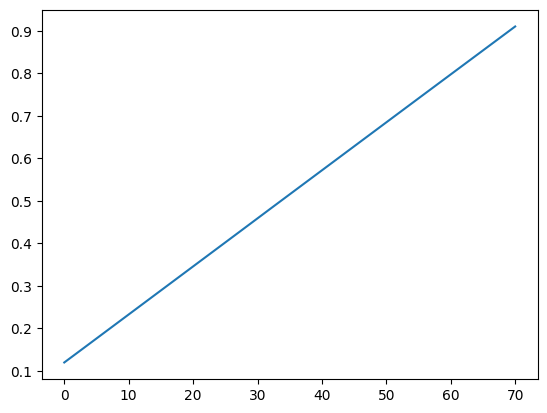

In [24]:
plt.plot(solution_rock.ts, jnp.sum(solution_rock.ys * domain.geometry.binary[None], axis=(1,2)) / jnp.sum(domain.geometry.binary[None]))

In [25]:
voltages = jax.vmap(eq.get_voltage)(solution_tsit.ys)

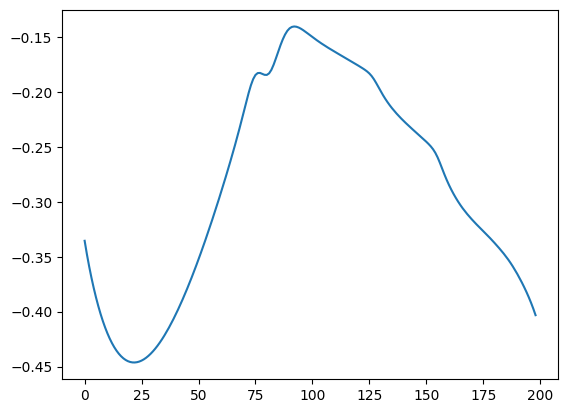

In [26]:
plt.plot(voltages[1:])